In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors

from scipy.stats import linregress

import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable


from pylab import rcParams
rcParams['axes.labelweight'] = 'bold'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'bold'

In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds

In [3]:
#import sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(60,-60), time = slice('1979', '2023'))

In [4]:
sst = sst.groupby('time.year').mean()

In [5]:
def compute_trend(data, time_axis=0):
    """
    Compute linear trend along the specified axis (time_axis).
    Returns the slope for each grid cell.
    """
    x = np.arange(data.shape[time_axis])  # Time indices
    slopes = np.apply_along_axis(
        lambda y: linregress(x, y).slope if np.isfinite(y).all() else np.nan,
        axis=time_axis,
        arr=data
    )
    return slopes

In [6]:
sst_trend = xr.apply_ufunc(
    compute_trend, sst.sst, input_core_dims=[['year']],
    vectorize=True
)

In [14]:
#lat trends

weights = np.cos(np.deg2rad(sst.lat))
mean_trend_lat = sst_trend.weighted(weights).mean('lon')

sst_trend_lat = sst_trend - mean_trend_lat


In [15]:
weights = np.cos(np.deg2rad(sst.lat))
mean_trend = sst_trend.weighted(weights).mean()

sst_trend_anomaly = sst_trend - mean_trend


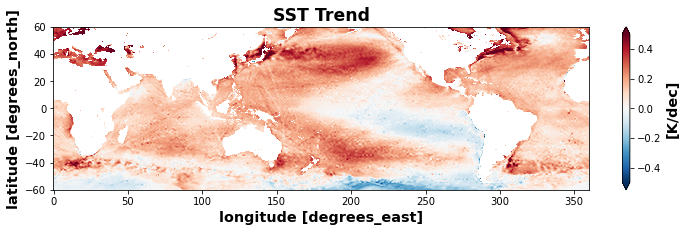

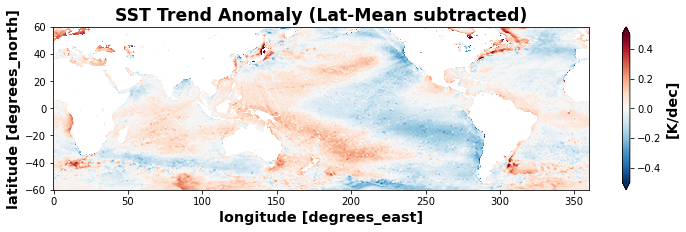

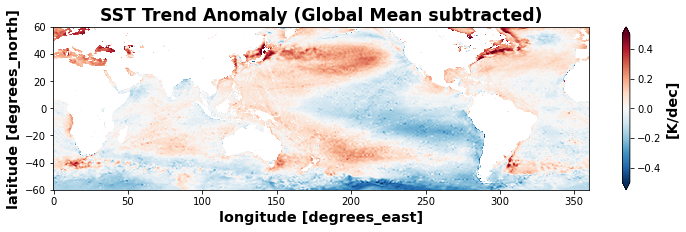

In [16]:
# Original trend map
plt.figure(figsize=(12, 3))
trend_plot = (10*sst_trend).plot(cmap='RdBu_r', extend='both', vmin = -0.5, vmax = 0.5)
trend_plot.colorbar.set_label('[K/dec]')  # Set the colorbar title

plt.title('SST Trend')
plt.show()

# Anomaly trend map
plt.figure(figsize=(12, 3))
anom_trend_plot = (10*sst_trend_lat).plot(cmap='RdBu_r', extend='both', vmin = -0.5, vmax = 0.5)
anom_trend_plot.colorbar.set_label('[K/dec]')  # Set the colorbar title

plt.title('SST Trend Anomaly (Lat-Mean subtracted)')
plt.show()

# Anomaly trend map
plt.figure(figsize=(12, 3))
anom_trend_plot = (10*sst_trend_anomaly).plot(cmap='RdBu_r', extend='both', vmin = -0.5, vmax = 0.5)
anom_trend_plot.colorbar.set_label('[K/dec]')  # Set the colorbar title

plt.title('SST Trend Anomaly (Global Mean subtracted)')
plt.show()